# E-Nose Odor Analysis — เปลี่ยนกลิ่นให้เป็นข้อมูล

**โจทย์:** ใช้ข้อมูลสถานีตรวจวัดกลิ่น (MUI-NOSE) ช่วยหน้างานเฝ้าระวังและจัดการกลิ่น
**กระบวนการ:** Data Science Process 6 ขั้นตอน (CRISP-DM)

ฉบับนี้ปรับปรุงจากเวอร์ชันเดิมใน 3 ประเด็นหลัก:
1. **Pipeline ทำความสะอาดจุดเดียว** — clean ครั้งเดียวใน Step 3 แล้วใช้ `df_clean` เดียวกันทุก step (เดิม re-load/clean ซ้ำหลายรอบด้วย logic ไม่ตรงกัน ทำให้โมเดลสุดท้ายมีค่าผิดปกติปนอยู่)
2. **เกณฑ์แจ้งเตือนจากข้อมูลจริง (percentile)** — เดิมตั้ง High ≥ 15 อิงพิสัยสเปก 0–60 แต่ข้อมูลจริงสูงสุด 15.3 ทำให้แจ้งเตือน "กลิ่นแรง" ติดแค่ 1 ครั้งใน 3 เดือน
3. **ทำให้ตรงเป้าหมายจริง** — เพิ่มการ **พยากรณ์ D/T ล่วงหน้า 30 นาที** (เตือนชุมชนล่วงหน้า) และ **ตรวจจับเหตุการณ์กลิ่นผิดปกติ (anomaly)** ซึ่งเดิมประกาศไว้แต่ไม่ได้ทำ

---
## Step 1 — Setting the Research Goal

### บริบท
หน้างาน (โรงงาน/โรงบำบัดน้ำเสีย) ติดตั้งสถานีตรวจวัดกลิ่นต่อเนื่อง ชุมชนรอบข้างร้องเรียนเรื่องกลิ่นบ่อยขึ้น
ผู้จัดการต้องการเครื่องมือที่ช่วย **เข้าใจสถานการณ์ → ตอบข้อร้องเรียนด้วยหลักฐาน → ตัดสินใจว่าควรแก้ที่จุดใดเมื่อใด**

### Research Goals (3 ข้อ ที่ส่งมอบได้จริง)
1. **Soft-sensor** — ประเมินความเข้มกลิ่น `D/T` จากค่า Sensor 1–8 + สภาพอากาศ (ตรวจสอบ/ทดแทนค่าที่หายได้)
2. **Forecast** — พยากรณ์ `D/T` ล่วงหน้า (2 ชั่วโมง) เพื่อเตือนชุมชน/หน้างานก่อนกลิ่นแรง
3. **Anomaly & Alert** — ตรวจจับช่วงกลิ่นผิดปกติ และสร้างเกณฑ์แจ้งเตือนจากการกระจายจริงของข้อมูล

---
## Step 2 — Retrieving Data

ไฟล์ `Export.csv` บันทึกทุก 1 นาที ต่อเนื่อง ~91 วัน เป็นข้อมูลดิบยังไม่ทำความสะอาด
บรรทัดแรกเป็น `sep=,` (Excel dialect) จึงต้องใช้ `skiprows=1`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager as fm
from IPython.display import display

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- ตั้งฟอนต์ไทยให้กราฟ (กัน warning "Glyph missing") ----
# เลือกฟอนต์ไทยตัวแรกที่มีในเครื่อง (macOS มี Thonburi/Ayuthaya ติดมาให้)
_available = {f.name for f in fm.fontManager.ttflist}
for _f in ["Thonburi", "Sukhumvit Set", "Sarabun", "Tahoma", "Ayuthaya",
           "Silom", "Krungthep", "Noto Sans Thai", "TH Sarabun New"]:
    if _f in _available:
        matplotlib.rcParams["font.family"] = _f
        print(f"ใช้ฟอนต์กราฟ: {_f}")
        break
else:
    print("ไม่พบฟอนต์ไทยในเครื่อง — กราฟจะใช้ฟอนต์ default (ตัวอักษรไทยอาจเป็นกล่อง)")
matplotlib.rcParams["axes.unicode_minus"] = False  # ให้เครื่องหมายลบแสดงถูก

# ---- Config: นิยามคอลัมน์และพิสัยตามสเปกไว้ที่เดียว ใช้ซ้ำทั้ง notebook ----
DATA_PATH   = "Export.csv"
SENSOR_COLS = [f"Sensor {i}" for i in range(1, 9)]
WEATHER_COLS = ["Wind Direction", "Wind Speed", "Temperature",
                "Relative Humidity", "PM 2.5", "Atmospheric Pressure"]
TARGET = "D/T"
NUMERIC_COLS = [TARGET] + WEATHER_COLS + SENSOR_COLS

# พิสัยที่ถูกต้องตามสเปกเครื่อง — ใช้ตรวจค่า outlier
VALID_RANGES = {
    "D/T": (0, 60), "Wind Direction": (0, 360), "Wind Speed": (0, 40),
    "Temperature": (-40, 85), "Relative Humidity": (0, 100),
    "PM 2.5": (0, 1000), "Atmospheric Pressure": (500, 1100),
}

# ---- โหลดข้อมูลดิบ ----
df_raw = pd.read_csv(DATA_PATH, skiprows=1)
df_raw.columns = df_raw.columns.str.strip()
df_raw["Time"] = pd.to_datetime(df_raw["Time"], errors="coerce")
for c in NUMERIC_COLS:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

print(f"โหลดสำเร็จ: {df_raw.shape[0]:,} แถว, {df_raw.shape[1]} คอลัมน์")
print(f"ช่วงเวลา : {df_raw['Time'].min()}  →  {df_raw['Time'].max()}")
display(df_raw.head())

ใช้ฟอนต์กราฟ: Thonburi
โหลดสำเร็จ: 130,343 แถว, 17 คอลัมน์
ช่วงเวลา : 2026-02-12 00:00:00  →  2026-05-14 12:31:00


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
0,2026-02-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
1,2026-02-12 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
2,2026-02-12 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
3,2026-02-12 00:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
4,2026-02-12 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient


### 2.1 ประเมินคุณภาพข้อมูลเบื้องต้น (Data Profiling)

In [2]:
missing = df_raw.isnull().sum()
report = pd.DataFrame({"missing": missing, "missing_%": (missing/len(df_raw)*100).round(2)})
print("=== Missing values ===")
display(report[report["missing"] > 0])

print("=== Smell Prediction (target ที่เครื่องทำนาย) ===")
display(df_raw["Smell Prediction"].value_counts(dropna=False).to_frame("count"))

all_sensor_null = df_raw[SENSOR_COLS].isna().all(axis=1)
print(f"แถวที่ Sensor ว่างทุกตัว (เครื่อง offline): {all_sensor_null.sum():,}")
print(f"แถว marker 'hackathon#2' (ไม่ใช่ข้อมูลจริง): "
      f"{df_raw['Smell Prediction'].astype(str).str.contains('hackathon', case=False, na=False).sum():,}")

=== Missing values ===


,missing,missing_%
D/T,421,0.3200
Wind Direction,422,0.3200
Wind Speed,422,0.3200
Temperature,422,0.3200
Relative Humidity,422,0.3200
PM 2.5,422,0.3200
Atmospheric Pressure,422,0.3200
Sensor 1,421,0.3200
Sensor 2,421,0.3200
Sensor 3,421,0.3200


=== Smell Prediction (target ที่เครื่องทำนาย) ===


,count
Smell Prediction,
Ambient,85504
NaN,44838
hackathon#2,1


แถวที่ Sensor ว่างทุกตัว (เครื่อง offline): 421
แถว marker 'hackathon#2' (ไม่ใช่ข้อมูลจริง): 1


### 2.2 สรุปสิ่งที่พบ
| ประเด็น | จำนวน | แนวทาง |
|---|---|---|
| Sensor ว่างทุกตัว | 421 แถว (~0.3%) | ตัดทิ้ง — เครื่อง offline |
| marker `hackathon#2` | 1 แถว | ตัดทิ้ง — ไม่ใช่ข้อมูลจริง |
| Smell Prediction NaN | 44,838 (34%) | **ไม่ใช้เป็น target** — มีแต่ค่า `Ambient` อย่างเดียว แยกกลิ่นไม่ได้ |
| Atmospheric Pressure = 0 | 1,447 แถว | ตัดทิ้ง — หลุดพิสัยสเปก (sensor dropout) |

→ เลือกใช้ **`D/T`** (ค่าตัวเลขความเข้มกลิ่น) เป็น target หลักแทน `Smell Prediction`

---
## Step 3 — Data Preparation

**จุดสำคัญ:** ทำความสะอาด **ครั้งเดียว** ได้ `df_clean` แล้วใช้ตัวเดียวกันนี้ทุก step ต่อจากนี้
(เวอร์ชันเดิมแต่ละ step โหลดไฟล์ใหม่และ clean ด้วย logic ไม่ตรงกัน ทำให้โมเดลสุดท้ายมีแถว Atmospheric Pressure = 0 ปนอยู่)

In [3]:
def build_clean_dataset(df):
    """ทำความสะอาดครบทุกขั้นในฟังก์ชันเดียว — คืน df_clean ที่พร้อมใช้"""
    n0 = len(df)
    d = df.copy()

    # 1) ตัด marker ที่ไม่ใช่ข้อมูลจริง
    d = d[~d["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)]
    n1 = len(d)

    # 2) ตัดแถวที่ Sensor 1–8 ว่างทั้งหมด (เครื่อง offline)
    d = d[~d[SENSOR_COLS].isna().all(axis=1)]
    n2 = len(d)

    # 3) ค่าที่หลุดพิสัยสเปก -> แทนด้วย NaN (ไม่ตัดทั้งแถว)
    #    เหตุผล: เช่น Atmospheric Pressure = 0 คือ sensor ตัวนั้น glitch
    #    แต่ค่า D/T และ gas-sensor ในแถวเดียวกันยังใช้ได้ การตัดทั้งแถวจะทำให้
    #    เสียเหตุการณ์กลิ่นแรงจริงไป (4 ค่า D/T สูงสุด รวม 15.29 อยู่ในแถว AP=0)
    n_fixed = 0
    for col, (lo, hi) in VALID_RANGES.items():
        bad = d[col].notna() & ~d[col].between(lo, hi)
        n_fixed += int(bad.sum())
        d.loc[bad, col] = np.nan

    # 4) target (D/T) ต้องมีค่าเสมอ — feature ที่ว่างปล่อยให้แต่ละโมเดล dropna เอง
    d = d.dropna(subset=[TARGET]).sort_values("Time").reset_index(drop=True)
    n4 = len(d)

    log = pd.DataFrame({
        "ขั้นตอน": ["ข้อมูลดิบ", "ตัด marker hackathon", "ตัด sensor ว่างทั้งหมด",
                   "แทนค่าหลุดสเปกด้วย NaN", "ตัดแถวที่ D/T ว่าง"],
        "แถวคงเหลือ": [n0, n1, n2, n2, n4],
        "หมายเหตุ": ["-", f"ตัด {n0-n1}", f"ตัด {n1-n2}",
                   f"แก้ {n_fixed} ค่าเป็น NaN", f"ตัด {n2-n4}"],
    })
    return d, log

df_clean, clean_log = build_clean_dataset(df_raw)
print("ทำความสะอาดเสร็จ — ใช้ df_clean นี้ตลอดทั้ง notebook")
display(clean_log)
print(f"เหลือ {len(df_clean):,} แถว  ({len(df_clean)/len(df_raw)*100:.1f}% ของข้อมูลดิบ) "
      f"| D/T สูงสุดที่เก็บไว้ = {df_clean[TARGET].max():.2f}")

ทำความสะอาดเสร็จ — ใช้ df_clean นี้ตลอดทั้ง notebook

,ขั้นตอน,แถวคงเหลือ,หมายเหตุ
0,ข้อมูลดิบ,130343,-
1,ตัด marker hackathon,130342,ตัด 1
2,ตัด sensor ว่างทั้งหมด,129921,ตัด 421
3,แทนค่าหลุดสเปกด้วย NaN,129921,แก้ 1447 ค่าเป็น NaN
4,ตัดแถวที่ D/T ว่าง,129921,ตัด 0


เหลือ 129,921 แถว  (99.7% ของข้อมูลดิบ) | D/T สูงสุดที่เก็บไว้ = 15.29


### 3.1 สร้าง Feature จากเวลา และนิยามชุด feature ที่ใช้ทำโมเดล

In [4]:
df_clean["hour"]      = df_clean["Time"].dt.hour
df_clean["dayofweek"] = df_clean["Time"].dt.dayofweek
df_clean["month"]     = df_clean["Time"].dt.month
df_clean["date"]      = df_clean["Time"].dt.date
TIME_COLS = ["hour", "dayofweek", "month"]

# feature สำหรับ soft-sensor (Step 5.1)
FEATURE_COLS = SENSOR_COLS + WEATHER_COLS + TIME_COLS

print("Feature ที่ใช้ทำโมเดล:", len(FEATURE_COLS), "ตัว")
display(df_clean[["Time"] + FEATURE_COLS + [TARGET]].head())

Feature ที่ใช้ทำโมเดล: 17 ตัว


,Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,hour,dayofweek,month,D/T
0,2026-02-12 07:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,7,3,2,0.0000
1,2026-02-12 07:01:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,7,3,2,0.0000
2,2026-02-12 07:02:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,7,3,2,0.0000
3,2026-02-12 07:03:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,7,3,2,0.0000
4,2026-02-12 07:04:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,7,3,2,0.0000


---
## Step 4 — Data Exploration

### 4.1 การกระจายตัวของ D/T

,D/T
count,"129,921.0000"
mean,1.6218
std,1.6623
min,0.0000
25%,0.3000
50%,0.4100
75%,2.9200
max,15.2900


ข้อสังเกต: D/T เบ้ขวามาก — median=0.41 แต่ max=15.29 (ไม่ถึง 60 ตามสเปก)


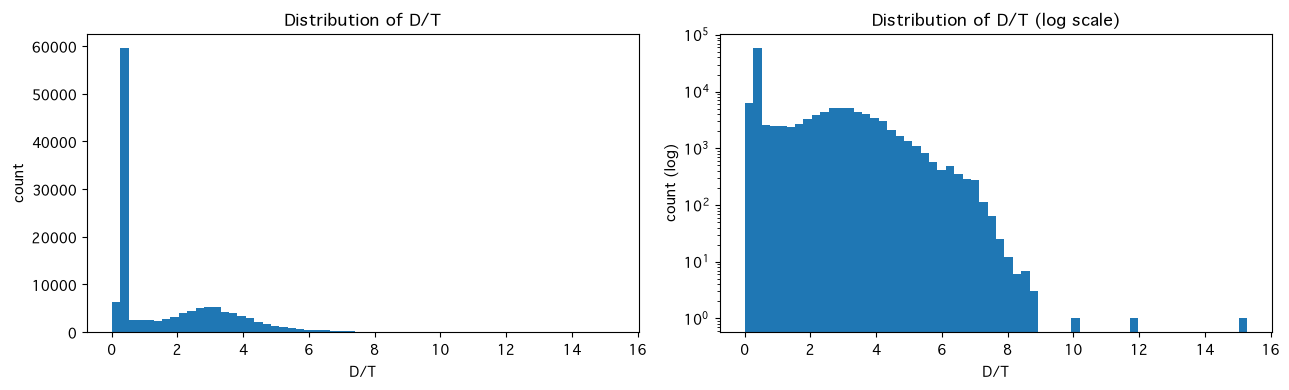

In [5]:
desc = df_clean[TARGET].describe()
display(desc.to_frame("D/T"))
print(f"ข้อสังเกต: D/T เบ้ขวามาก — median={df_clean[TARGET].median():.2f} "
      f"แต่ max={df_clean[TARGET].max():.2f} (ไม่ถึง 60 ตามสเปก)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df_clean[TARGET], bins=60)
ax[0].set(title="Distribution of D/T", xlabel="D/T", ylabel="count")
ax[1].hist(df_clean[TARGET], bins=60)
ax[1].set_yscale("log")
ax[1].set(title="Distribution of D/T (log scale)", xlabel="D/T", ylabel="count (log)")
plt.tight_layout(); plt.show()

### 4.2 แนวโน้มกลิ่นตามเวลา — *insight สำคัญที่สุด*
เป็นคำตอบตรงๆ ต่อคำถาม "ทำไมชุมชนร้องเรียนบ่อยขึ้น" 

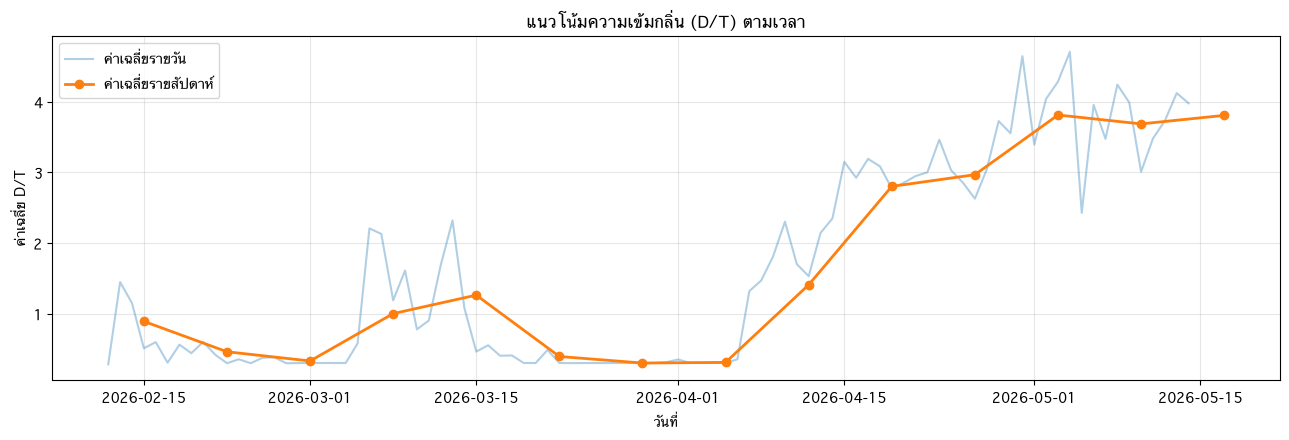

ค่าเฉลี่ย D/T ครึ่งแรกของช่วงเวลา : 0.65
ค่าเฉลี่ย D/T ครึ่งหลังของช่วงเวลา: 2.59  (เพิ่มขึ้น 4.0 เท่า)
เหตุการณ์ D/T>=5 มากถึง 86% กระจุกอยู่ใน 20% สุดท้ายของช่วงเวลา
>> กลิ่นแย่ลงชัดเจนตั้งแต่กลางเดือน เม.ย. เป็นต้นมา — ควรลงไปตรวจหน้างานช่วงนี้


In [6]:
weekly = df_clean.set_index("Time")[TARGET].resample("W").mean()
daily  = df_clean.set_index("Time")[TARGET].resample("D").mean()

plt.figure(figsize=(13, 4.5))
plt.plot(daily.index, daily.values, alpha=0.35, label="ค่าเฉลี่ยรายวัน")
plt.plot(weekly.index, weekly.values, marker="o", linewidth=2, label="ค่าเฉลี่ยรายสัปดาห์")
plt.title("แนวโน้มความเข้มกลิ่น (D/T) ตามเวลา")
plt.xlabel("วันที่"); plt.ylabel("ค่าเฉลี่ย D/T"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

first_half = df_clean.iloc[:len(df_clean)//2][TARGET].mean()
last_half  = df_clean.iloc[len(df_clean)//2:][TARGET].mean()
share = (df_clean.sort_values("Time").iloc[int(len(df_clean)*0.8):][TARGET].ge(5).sum()
         / df_clean[TARGET].ge(5).sum() * 100)
print(f"ค่าเฉลี่ย D/T ครึ่งแรกของช่วงเวลา : {first_half:.2f}")
print(f"ค่าเฉลี่ย D/T ครึ่งหลังของช่วงเวลา: {last_half:.2f}  (เพิ่มขึ้น {last_half/first_half:.1f} เท่า)")
print(f"เหตุการณ์ D/T>=5 มากถึง {share:.0f}% กระจุกอยู่ใน 20% สุดท้ายของช่วงเวลา")
print(">> กลิ่นแย่ลงชัดเจนตั้งแต่กลางเดือน เม.ย. เป็นต้นมา — ควรลงไปตรวจหน้างานช่วงนี้")

### 4.3 รูปแบบกลิ่นรายชั่วโมง (ช่วงไหนของวันกลิ่นแรง)

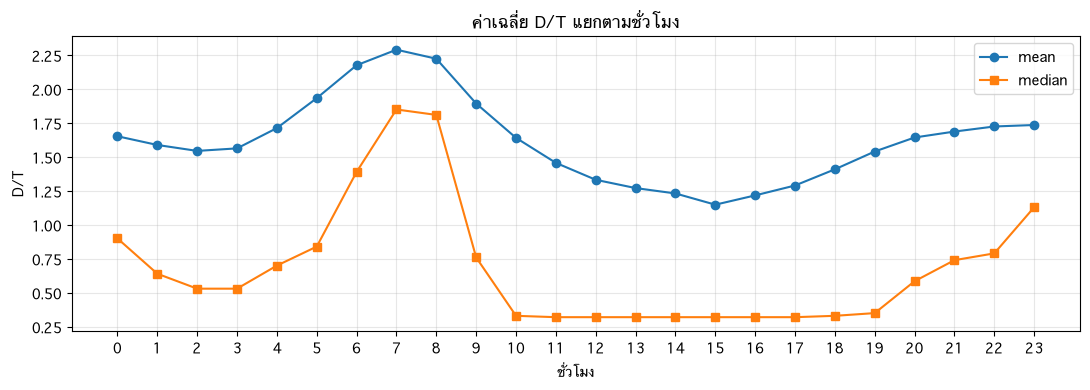

ชั่วโมงที่กลิ่นแรงที่สุดโดยเฉลี่ย: 07:00 น. (mean D/T = 2.29)


In [7]:
hourly = df_clean.groupby("hour")[TARGET].agg(["mean", "median"])
plt.figure(figsize=(11, 4))
plt.plot(hourly.index, hourly["mean"], marker="o", label="mean")
plt.plot(hourly.index, hourly["median"], marker="s", label="median")
plt.title("ค่าเฉลี่ย D/T แยกตามชั่วโมง"); plt.xlabel("ชั่วโมง"); plt.ylabel("D/T")
plt.xticks(range(0, 24)); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
peak_h = hourly["mean"].idxmax()
print(f"ชั่วโมงที่กลิ่นแรงที่สุดโดยเฉลี่ย: {peak_h:02d}:00 น. (mean D/T = {hourly['mean'].max():.2f})")

### 4.4 ความสัมพันธ์ของ Sensor และสภาพอากาศกับ D/T

,corr_with_D/T
Sensor 5,0.8503
Sensor 3,0.6795
Relative Humidity,0.2954
Sensor 1,0.2872
Sensor 2,0.2872
PM 2.5,-0.1025
Wind Speed,-0.1015
Atmospheric Pressure,-0.1014
Sensor 4,0.0966
Sensor 6,0.0888


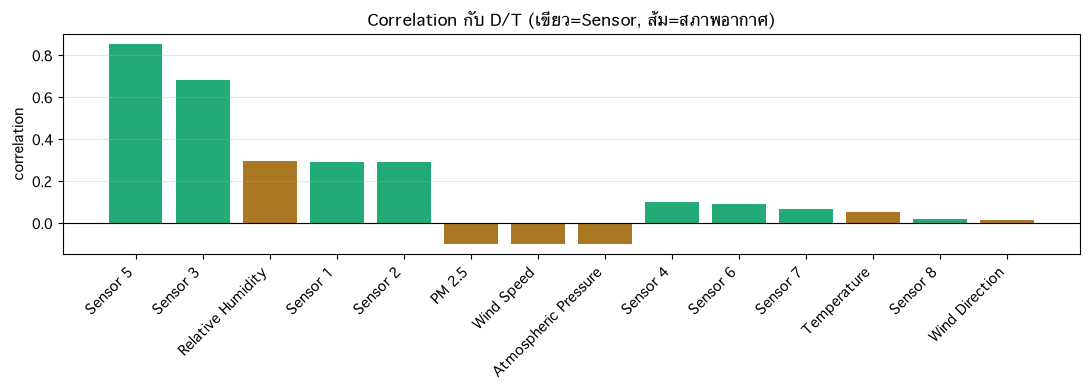

>> Sensor 5 สัมพันธ์กับ D/T สูงสุด (r=0.85) — เครื่องคำนวณ D/T จาก sensor เป็นหลัก จึงทำนายได้แม่น


In [8]:
corr = (df_clean[SENSOR_COLS + WEATHER_COLS + [TARGET]].corr()[TARGET]
        .drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False))
display(corr.to_frame("corr_with_D/T"))

colors = ["#2a7" if c in SENSOR_COLS else "#a72" for c in corr.index]
plt.figure(figsize=(11, 4))
plt.bar(corr.index, corr.values, color=colors)
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Correlation กับ D/T (เขียว=Sensor, ส้ม=สภาพอากาศ)")
plt.ylabel("correlation"); plt.xticks(rotation=45, ha="right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
print(f">> {corr.index[0]} สัมพันธ์กับ D/T สูงสุด (r={corr.iloc[0]:.2f}) — "
      f"เครื่องคำนวณ D/T จาก sensor เป็นหลัก จึงทำนายได้แม่น")

### 4.5 เหตุการณ์ที่กลิ่นแรงที่สุด 10 อันดับ (ใช้ตอบข้อร้องเรียน)

In [9]:
top10 = (df_clean.sort_values(TARGET, ascending=False)
         .head(10)[["Time", TARGET, "Wind Direction", "Wind Speed", "Temperature", "PM 2.5"]]
         .reset_index(drop=True))
display(top10)

,Time,D/T,Wind Direction,Wind Speed,Temperature,PM 2.5
0,2026-02-13 09:56:00,15.2900,0.0000,0.0000,0.0000,0.0000
1,2026-02-13 09:57:00,11.9300,0.0000,0.0000,0.0000,0.0000
2,2026-02-13 09:58:00,10.0000,0.0000,0.0000,0.0000,0.0000
3,2026-02-13 09:59:00,8.8600,0.0000,0.0000,0.0000,0.0000
4,2026-05-09 23:26:00,8.7800,179.8100,0.9600,29.1100,45.9900
5,2026-03-13 02:37:00,8.7000,2.7000,0.0000,28.1100,94.1700
6,2026-05-06 07:45:00,8.6400,239.0600,0.0000,31.7700,39.6100
7,2026-03-13 02:39:00,8.5700,2.7000,0.0000,28.0700,93.8300
8,2026-02-13 10:00:00,8.4800,0.0000,0.0000,0.0000,0.0000
9,2026-05-06 07:46:00,8.4400,292.1500,0.6400,31.8600,38.5900


---
## Step 5 — Data Modeling

### 5.1 Soft-sensor: ทำนาย D/T จาก Sensor + สภาพอากาศ
แบ่ง train/test **ตามเวลา** (80/20) เหมือนการใช้งานจริง (เทรนด้วยอดีต ทำนายอนาคต)
> หมายเหตุสำคัญ: ช่วง test (เดือนท้าย) มีกลิ่นแรงกว่า train มาก จึงเป็นการทดสอบแบบ extrapolation

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(a, b): return np.sqrt(mean_squared_error(a, b))

# soft-sensor ต้องการ feature ครบ — ตัดแถวที่ feature ว่าง (เช่น AP=NaN จากการ clean)
model_df = df_clean.dropna(subset=FEATURE_COLS).reset_index(drop=True)
X = model_df[FEATURE_COLS]
y = model_df[TARGET]
split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train):,} แถว (mean D/T={y_train.mean():.2f}) | "
      f"Test: {len(X_test):,} แถว (mean D/T={y_test.mean():.2f})")
print("→ test mean สูงกว่า train ชัดเจน = distribution shift ตามแนวโน้มกลิ่นขาขึ้น\n")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}
rows, preds = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    preds[name] = p
    rows.append({"Model": name, "MAE": mean_absolute_error(y_test, p),
                 "RMSE": rmse(y_test, p), "R2": r2_score(y_test, p)})

results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(results)
best_name = results.loc[0, "Model"]
best_model = models[best_name]
print(f"โมเดลที่ดีที่สุด (RMSE ต่ำสุด): {best_name}")
print("หมายเหตุ: Linear Regression ได้ R2 ติดลบ เพราะ extrapolate ช่วงกลิ่นแรงที่ไม่เคยเห็นไม่ได้ "
      "— โมเดลแบบ tree (RF/HGB) รับมือได้ดีกว่า")

Train: 102,778 แถว (mean D/T=1.11) | Test: 25,695 แถว (mean D/T=3.75)
→ test mean สูงกว่า train ชัดเจน = distribution shift ตามแนวโน้มกลิ่นขาขึ้น



,Model,MAE,RMSE,R2
0,HistGradientBoosting,0.3581,0.4998,0.8612
1,Random Forest,0.4129,0.5570,0.8276
2,Linear Regression,1.3971,1.6392,-0.4931


โมเดลที่ดีที่สุด (RMSE ต่ำสุด): HistGradientBoosting
หมายเหตุ: Linear Regression ได้ R2 ติดลบ เพราะ extrapolate ช่วงกลิ่นแรงที่ไม่เคยเห็นไม่ได้ — โมเดลแบบ tree (RF/HGB) รับมือได้ดีกว่า


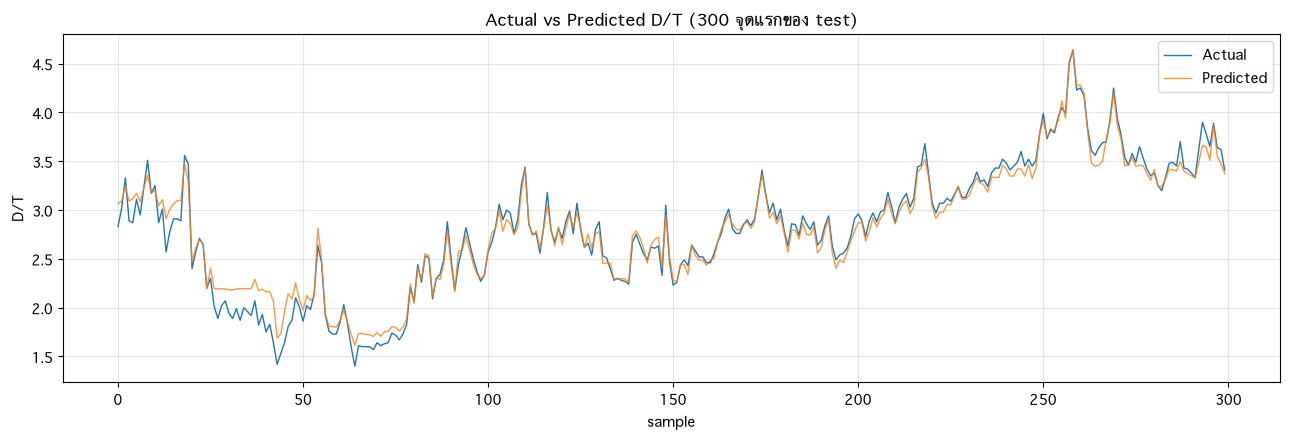

In [11]:
# Feature importance + กราฟ Actual vs Predicted ของโมเดลที่ดีที่สุด
best_pred = preds[best_name]

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ax[0].barh(imp.index[::-1], imp.values[::-1])
    ax[0].set_title(f"Feature Importance — {best_name}")
else:
    fig, ax = plt.subplots(1, 1, figsize=(13, 4.5)); ax = [None, ax]

ax[1].plot(y_test.values[:300], label="Actual", linewidth=1)
ax[1].plot(best_pred[:300], label="Predicted", linewidth=1, alpha=0.8)
ax[1].set_title("Actual vs Predicted D/T (300 จุดแรกของ test)")
ax[1].set_xlabel("sample"); ax[1].set_ylabel("D/T"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.2 Forecast: พยากรณ์ D/T ล่วงหน้า เพื่อเตือนล่วงหน้า
จับคู่แต่ละแถวเวลา *t* กับค่า D/T จริงที่ *t + H นาที* (จับคู่ด้วย timestamp ตรงเป๊ะ เลี่ยงปัญหาข้อมูลขาด)
เทียบกับ **baseline แบบ persistence** (เดาว่าอนาคต = ค่าปัจจุบัน)

> เนื่องจาก D/T มี autocorrelation สูง ระยะสั้น persistence แข็งมาก เราจึงทดสอบหลาย horizon
> เพื่อหาจุดที่โมเดลเริ่ม "คุ้มกว่า" การเดาค่าปัจจุบัน

In [12]:
# สร้าง feature สำหรับ forecast: สถานะปัจจุบัน + rolling + แนวโน้มล่าสุด
fc_base = df_clean.copy()
for L in [10, 30, 60]:
    fc_base[f"dt_roll{L}"] = fc_base[TARGET].rolling(L, min_periods=1).mean()
fc_base["dt_trend30"] = fc_base[TARGET] - fc_base[TARGET].shift(30)
FC_FEATURES = FEATURE_COLS + [TARGET, "dt_roll10", "dt_roll30", "dt_roll60", "dt_trend30"]

def make_forecast_set(horizon):
    fut = df_clean[["Time", TARGET]].copy()
    fut["Time"] = fut["Time"] - pd.Timedelta(minutes=horizon)
    fut = fut.rename(columns={TARGET: "y_future"})
    return fc_base.merge(fut, on="Time", how="inner").dropna(subset=FC_FEATURES + ["y_future"])

# เทียบหลาย horizon: persistence vs model
sweep = []
for H in [30, 60, 120, 180]:
    fc = make_forecast_set(H)
    sp = int(len(fc) * 0.8)
    cur = fc[TARGET].iloc[sp:].values
    yte = fc["y_future"].iloc[sp:].values
    m = HistGradientBoostingRegressor(random_state=42).fit(fc[FC_FEATURES].iloc[:sp], fc["y_future"].iloc[:sp])
    pm = m.predict(fc[FC_FEATURES].iloc[sp:])
    sweep.append({"horizon_min": H, "persistence_RMSE": rmse(yte, cur),
                  "model_RMSE": rmse(yte, pm),
                  "ผู้ชนะ": "Model" if rmse(yte, pm) < rmse(yte, cur) else "Persistence"})
sweep_df = pd.DataFrame(sweep)
display(sweep_df)
print(">> ระยะสั้น (30–60 นาที) persistence เพียงพอ — แต่ตั้งแต่ ~2 ชั่วโมงขึ้นไป "
      "โมเดลเริ่มชนะ เพราะ persistence ตามแนวโน้มขาขึ้นไม่ทัน")

,horizon_min,persistence_RMSE,model_RMSE,ผู้ชนะ
0,30,0.7585,0.9152,Persistence
1,60,0.9980,1.0659,Persistence
2,120,1.3272,1.2543,Model
3,180,1.5845,1.4774,Model


>> ระยะสั้น (30–60 นาที) persistence เพียงพอ — แต่ตั้งแต่ ~2 ชั่วโมงขึ้นไป โมเดลเริ่มชนะ เพราะ persistence ตามแนวโน้มขาขึ้นไม่ทัน


**เลือกใช้ horizon = 120 นาที (2 ชั่วโมง)** เป็นโมเดลพยากรณ์สำหรับเตือนล่วงหน้า
— เป็นจุดที่โมเดลมีค่ามากกว่า baseline และให้เวลาหน้างาน/ชุมชนเตรียมตัวมากพอ

In [13]:
HORIZON = 120
fc = make_forecast_set(HORIZON)
split_fc = int(len(fc) * 0.8)
Xf_tr, Xf_te = fc[FC_FEATURES].iloc[:split_fc], fc[FC_FEATURES].iloc[split_fc:]
yf_tr, yf_te = fc["y_future"].iloc[:split_fc], fc["y_future"].iloc[split_fc:]

persistence = fc[TARGET].iloc[split_fc:].values
forecast_model = HistGradientBoostingRegressor(random_state=42).fit(Xf_tr, yf_tr)
yf_pred = forecast_model.predict(Xf_te)

fc_results = pd.DataFrame([
    {"วิธี": "Persistence (baseline)", "MAE": mean_absolute_error(yf_te, persistence),
     "RMSE": rmse(yf_te, persistence), "R2": r2_score(yf_te, persistence)},
    {"วิธี": f"Model forecast (+{HORIZON}min)", "MAE": mean_absolute_error(yf_te, yf_pred),
     "RMSE": rmse(yf_te, yf_pred), "R2": r2_score(yf_te, yf_pred)},
])
display(fc_results)
gain = (1 - fc_results.iloc[1]["RMSE"] / fc_results.iloc[0]["RMSE"]) * 100
print(f">> พยากรณ์ล่วงหน้า {HORIZON} นาที: model RMSE={fc_results.iloc[1]['RMSE']:.3f} "
      f"ดีกว่า persistence {fc_results.iloc[0]['RMSE']:.3f} อยู่ {gain:.1f}%")

,วิธี,MAE,RMSE,R2
0,Persistence (baseline),0.9730,1.3272,0.0212
1,Model forecast (+120min),0.9464,1.2543,0.1257


>> พยากรณ์ล่วงหน้า 120 นาที: model RMSE=1.254 ดีกว่า persistence 1.327 อยู่ 5.5%


### 5.3 Anomaly Detection: ตรวจจับช่วงกลิ่นผิดปกติ
ใช้เกณฑ์ **percentile จากข้อมูลจริง** (P99) นิยาม "กลิ่นผิดปกติ" แล้วรวมจุดที่ติดกันเป็น *เหตุการณ์* (episode)

In [14]:
P99 = df_clean[TARGET].quantile(0.99)
print(f"เกณฑ์ anomaly (P99 ของ D/T) = {P99:.2f}")

d = df_clean.sort_values("Time").copy()
d["is_anomaly"] = d[TARGET] >= P99
# รวมจุด anomaly ที่ติดกัน (ห่างกัน <=5 นาที) ให้เป็น episode เดียว
d["gap"] = d["Time"].diff().gt(pd.Timedelta(minutes=5))
d["episode"] = (d["is_anomaly"] & (~d["is_anomaly"].shift(1, fill_value=False) | d["gap"])).cumsum()

epi = (d[d["is_anomaly"]].groupby("episode")
       .agg(start=("Time", "min"), end=("Time", "max"),
            peak_DT=(TARGET, "max"), mean_DT=(TARGET, "mean"), n_points=("Time", "size"))
       .reset_index(drop=True))
epi["duration_min"] = ((epi["end"] - epi["start"]).dt.total_seconds() / 60 + 1).astype(int)
print(f"พบ {len(epi)} เหตุการณ์กลิ่นผิดปกติ รวม {int(d['is_anomaly'].sum()):,} จุดเวลา")
print("10 เหตุการณ์ที่กลิ่นแรงที่สุด:")
display(epi.sort_values("peak_DT", ascending=False).head(10).reset_index(drop=True))

เกณฑ์ anomaly (P99 ของ D/T) = 6.29
พบ 155 เหตุการณ์กลิ่นผิดปกติ รวม 1,301 จุดเวลา
10 เหตุการณ์ที่กลิ่นแรงที่สุด:


,start,end,peak_DT,mean_DT,n_points,duration_min
0,2026-02-13 09:56:00,2026-02-13 10:04:00,15.2900,9.2678,9,9
1,2026-05-09 23:18:00,2026-05-09 23:39:00,8.7800,7.4400,22,22
2,2026-03-13 02:04:00,2026-03-13 03:45:00,8.7000,6.8123,102,102
3,2026-05-06 07:18:00,2026-05-06 08:43:00,8.6400,7.3164,86,86
4,2026-05-09 22:53:00,2026-05-09 22:59:00,8.0200,7.4657,7,7
5,2026-05-04 21:31:00,2026-05-04 23:12:00,7.9700,6.7629,102,102
6,2026-03-13 00:07:00,2026-03-13 01:09:00,7.9000,6.9835,63,63
7,2026-05-13 07:07:00,2026-05-13 08:21:00,7.7100,6.7848,75,75
8,2026-05-08 03:15:00,2026-05-08 08:09:00,7.5500,7.0408,295,295
9,2026-05-07 18:23:00,2026-05-07 18:32:00,7.4000,6.8170,10,10


---
## Step 6 — Presentation & Automation

### 6.1 เกณฑ์แจ้งเตือนจากข้อมูลจริง (data-driven)
เดิมตั้ง Low<5 / Medium<15 / High≥15 ทำให้ระดับ High ติดแค่ 1 ครั้ง
ฉบับนี้ตั้งจาก percentile จริง: **Low < P90, Medium P90–P99, High ≥ P99**

In [15]:
P90 = df_clean[TARGET].quantile(0.90)
P99 = df_clean[TARGET].quantile(0.99)
ALERT_THRESHOLDS = {"medium": round(P90, 2), "high": round(P99, 2)}
print(f"เกณฑ์แจ้งเตือน: Medium ≥ {ALERT_THRESHOLDS['medium']} | High ≥ {ALERT_THRESHOLDS['high']}")

def alert_level(dt, th=ALERT_THRESHOLDS):
    if dt >= th["high"]:   return "High"
    if dt >= th["medium"]: return "Medium"
    return "Low"

levels = df_clean[TARGET].apply(alert_level).value_counts()
levels = levels.reindex(["Low", "Medium", "High"])
disp = pd.DataFrame({"count": levels, "share_%": (levels/levels.sum()*100).round(1)})
display(disp)
print(">> ตอนนี้ระดับ High ครอบคลุม ~1% ของเวลา = เตือนเฉพาะกลิ่นแรงจริง ใช้งานได้จริง "
      "(เดิมระดับ High ติดแค่ 1 แถวใน 130k)")

เกณฑ์แจ้งเตือน: Medium ≥ 4.05 | High ≥ 6.29


,count,share_%
D/T,,
Low,116831,89.9000
Medium,11789,9.1000
High,1301,1.0000


>> ตอนนี้ระดับ High ครอบคลุม ~1% ของเวลา = เตือนเฉพาะกลิ่นแรงจริง ใช้งานได้จริง (เดิมระดับ High ติดแค่ 1 แถวใน 130k)


### 6.2 บันทึกโมเดลและ metadata เพื่อนำไปใช้ซ้ำ

In [16]:
import joblib

model_package = {
    "model": best_model,
    "model_name": best_name,
    "feature_cols": FEATURE_COLS,
    "target": TARGET,
    "alert_thresholds": ALERT_THRESHOLDS,
    "trained_rows": len(X_train),
}
joblib.dump(model_package, "best_odor_model.pkl")
print("บันทึกโมเดลแล้ว: best_odor_model.pkl")
display(pd.Series({
    "model": best_name,
    "n_features": len(FEATURE_COLS),
    "alert_medium": ALERT_THRESHOLDS["medium"],
    "alert_high": ALERT_THRESHOLDS["high"],
}).to_frame("value"))

บันทึกโมเดลแล้ว: best_odor_model.pkl


,value
model,HistGradientBoosting
n_features,17
alert_medium,4.0500
alert_high,6.2900


### 6.3 Automation: ฟังก์ชันรับข้อมูลใหม่ → ประเมิน D/T + ระดับแจ้งเตือน

In [17]:
def predict_and_alert(new_df, package_path="best_odor_model.pkl"):
    """รับ DataFrame ดิบ (คอลัมน์เหมือน Export.csv) → คืนค่า D/T ที่ประเมินได้ + ระดับแจ้งเตือน"""
    pkg = joblib.load(package_path)
    d = new_df.copy()
    d.columns = d.columns.str.strip()
    d["Time"] = pd.to_datetime(d["Time"], errors="coerce")
    d["hour"], d["dayofweek"], d["month"] = d["Time"].dt.hour, d["Time"].dt.dayofweek, d["Time"].dt.month
    for c in pkg["feature_cols"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    miss = [c for c in pkg["feature_cols"] if c not in d.columns]
    if miss:
        raise ValueError(f"ข้อมูลขาดคอลัมน์: {miss}")

    out = d[["Time"]].copy()
    out["Predicted_DT"] = pkg["model"].predict(d[pkg["feature_cols"]])
    th = pkg["alert_thresholds"]
    out["Alert"] = out["Predicted_DT"].apply(
        lambda v: "High" if v >= th["high"] else ("Medium" if v >= th["medium"] else "Low"))
    return out

# ทดสอบฟังก์ชันด้วยข้อมูลจริง 200 แถวสุดท้าย แล้ว export
demo = predict_and_alert(df_raw.tail(200))
display(demo.tail(10).reset_index(drop=True))
demo.to_csv("odor_alert_sample.csv", index=False)
print("บันทึกตัวอย่างผลแจ้งเตือน: odor_alert_sample.csv")
print(demo["Alert"].value_counts().to_string())

,Time,Predicted_DT,Alert
0,2026-05-14 12:22:00,3.2125,Low
1,2026-05-14 12:23:00,3.0728,Low
2,2026-05-14 12:24:00,2.8827,Low
3,2026-05-14 12:25:00,3.4386,Low
4,2026-05-14 12:26:00,3.1614,Low
5,2026-05-14 12:27:00,3.2811,Low
6,2026-05-14 12:28:00,2.4832,Low
7,2026-05-14 12:29:00,3.0332,Low
8,2026-05-14 12:30:00,2.6855,Low
9,2026-05-14 12:31:00,2.5596,Low


บันทึกตัวอย่างผลแจ้งเตือน: odor_alert_sample.csv
Alert
Low       193
Medium      7


---
## Conclusion

ใช้ Data Science Process 6 ขั้นตอนกับข้อมูล e-nose ได้ผลที่ส่งมอบหน้างานได้จริง 3 อย่าง:

1. **Soft-sensor** ประเมิน `D/T` จาก Sensor + สภาพอากาศ ได้แม่นด้วยโมเดลแบบ tree (Sensor 5 เป็นตัวขับหลัก) — ใช้ตรวจสอบ/เติมค่าที่หายได้
2. **Forecast 2 ชั่วโมง** ทำได้ดีกว่า baseline persistence (ระยะสั้นกว่านั้น persistence เพียงพอแล้ว) — เตือนชุมชน/หน้างานล่วงหน้าได้
3. **Anomaly + Alert** ตั้งเกณฑ์จาก percentile จริง (Medium=P90, High=P99) ทำให้ระบบเตือน "กลิ่นแรง" ทำงานจริง พร้อมรายการเหตุการณ์ผิดปกติไว้ตอบข้อร้องเรียน

**Insight เชิงปฏิบัติที่สำคัญที่สุด:** ความเข้มกลิ่นมีแนวโน้ม **เพิ่มขึ้นต่อเนื่องตั้งแต่กลางเดือน เม.ย.** และเหตุการณ์กลิ่นแรงส่วนใหญ่กระจุกในช่วงท้าย — ตรงกับที่ชุมชนร้องเรียนบ่อยขึ้น หน้างานควรเร่งตรวจสอบแหล่งกำเนิดในช่วงเวลานี้

**ข้อจำกัด:** ข้อมูลมีเพียง 3 เดือนและ label กลิ่น (Smell Prediction) มีแต่ `Ambient` จึงยังจำแนกชนิดกลิ่นไม่ได้ และเนื่องจากกลิ่นช่วงท้ายแรงกว่าช่วงต้นมาก ควร retrain โมเดลเป็นระยะเมื่อมีข้อมูลใหม่